In [2]:
metrics_filename = "metrics.json"
output_dir = "/home/s4861264/detectron2/projects/LoTSS-GRG-detect/output/"
results_dir = "/home/s4861264/detectron2/projects/LoTSS-GRG-detect/results/"

In [3]:
import json
import os

# Read line by line, every line is a json object
def read_metrics(metrics_file):
    grg_metrics = {}
    coco_metrics = {}
    total_loss = []
    with open(metrics_file, "r") as f:
        for line in f:
            # Line is a dictionary in json format
            metrics = json.loads(line)
            for key, value in metrics.items():
                if key.startswith("GRG/"):
                    if key not in grg_metrics:
                        grg_metrics[key] = []
                    grg_metrics[key].append(value)
                elif key.startswith("bbox/") or key.startswith("segm/"):
                    if key not in coco_metrics:
                        coco_metrics[key] = []
                    coco_metrics[key].append(value)
                elif key == "total_loss":
                    total_loss.append(value)
    return grg_metrics, coco_metrics, total_loss

def read_metrics_racun(metrics_file):
    b2s_metrics = {}
    b2s_mcs_metrics = {}
    b2s_scs_metrics = {}
    loss_box_reg = []
    loss_cls = []
    loss_mask = []
    total_loss = []
    with open(metrics_file, "r") as f:
        for line in f:
            # Line is a dictionary in json format
            try:
                metrics = json.loads(line)
            except json.JSONDecodeError:
                continue
            for key, value in metrics.items():
                # Metrics
                if key.startswith("B2S/"):
                    metric_name = key.split("/")[-1]

                    if metric_name not in b2s_metrics:
                        b2s_metrics[metric_name] = []
                    b2s_metrics[metric_name].append(value)

                if key.startswith("B2S_CLASSWISE/MCS_"):
                    metric_name = key.split("/MCS_")[-1]

                    if any(x in metric_name for x in ["tp", "fp", "fn"]):
                        continue  # Skip raw counts

                    if metric_name not in b2s_mcs_metrics:
                        b2s_mcs_metrics[metric_name] = []
                    b2s_mcs_metrics[metric_name].append(value)

                if key.startswith("B2S_CLASSWISE/SCS_"):
                    metric_name = key.split("/SCS_")[-1]

                    if any(x in metric_name for x in ["tp", "fp", "fn"]):
                        continue  # Skip raw counts

                    if metric_name not in b2s_scs_metrics:
                        b2s_scs_metrics[metric_name] = []
                    b2s_scs_metrics[metric_name].append(value)

                # Losses
                if key == "loss_box_reg":
                    loss_box_reg.append(value)
                elif key == "loss_cls":
                    loss_cls.append(value)
                elif key == "loss_mask":
                    loss_mask.append(value)
                elif key == "total_loss":
                    total_loss.append(value)

    return b2s_metrics, b2s_mcs_metrics, b2s_scs_metrics, loss_box_reg, loss_cls, loss_mask, total_loss

def display_b2s_metrics(metrics_file):
    metrics_file = os.path.join(output_dir, metrics_file, metrics_filename)
    import matplotlib.pyplot as plt
    b2s_metrics, b2s_mcs_metrics, b2s_scs_metrics, loss_box_reg, loss_cls, loss_mask, total_loss = read_metrics_racun(metrics_file)

    
    # Run a running average with window size 10 for better visualization of trends
    def running_average(data, window_size=40):
        if len(data) < window_size:
            return data  # Not enough data for running average
        return [sum(data[i:i+window_size])/window_size for i in range(len(data)-window_size+1)]

    total_loss = running_average(total_loss)
    loss_box_reg = running_average(loss_box_reg)
    loss_cls = running_average(loss_cls)
    loss_mask = running_average(loss_mask)

    plt.plot(total_loss, label="total_loss")
    plt.plot(loss_box_reg, label="loss_box_reg")
    plt.plot(loss_cls, label="loss_cls")
    plt.plot(loss_mask, label="loss_mask")
    plt.yscale("log")  # Use logarithmic scale for better visibility of loss trends
    plt.legend()
    plt.title("Losses")
    plt.show()

    segmentation_metrics = {k: v for k, v in b2s_metrics.items() if "segm" in k}
    bbox_metrics = {k: v for k, v in b2s_metrics.items() if "bbox" in k}

    # Plot B2S metrics for segmentation
    for key, value in segmentation_metrics.items():
        max_val = max(value)
        plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S Segmentation Metrics")
    plt.show()

    # Plot B2S metrics for bounding boxes
    for key, value in bbox_metrics.items():
        max_val = max(value)
        plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S Bounding Box Metrics")
    plt.show()

    # B2S MCS segmentation metrics
    for key, value in b2s_mcs_metrics.items():
        if "segm" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S MCS Segmentation Metrics")
    plt.show()

    # B2S MCS bbox metrics
    for key, value in b2s_mcs_metrics.items():
        if "bbox" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S MCS Bounding Box Metrics")
    plt.show()

    # B2S SCS segmentation metrics
    for key, value in b2s_scs_metrics.items():
        if "segm" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S SCS Segmentation Metrics")
    plt.show()

    # B2S SCS bbox metrics
    for key, value in b2s_scs_metrics.items():
        if "bbox" in key:
            max_val = max(value)
            plt.plot(value, label=f"{key} (max={max_val:.4f})")
    plt.legend()
    plt.title("B2S SCS Bounding Box Metrics")
    plt.show()

    mcs_metrics = {k: v for k, v in b2s_mcs_metrics.items() if "segm" in k or "bbox" in k}
    scs_metrics = {k: v for k, v in b2s_scs_metrics.items() if "segm" in k or "bbox" in k}
    overall_metrics = {k: v for k, v in b2s_metrics.items() if "segm" in k or "bbox" in k}
    print("Final B2S Metrics:")
    print("MCS metrics:", mcs_metrics)
    print("SCS metrics:", scs_metrics)
    print("Overall metrics:", overall_metrics)

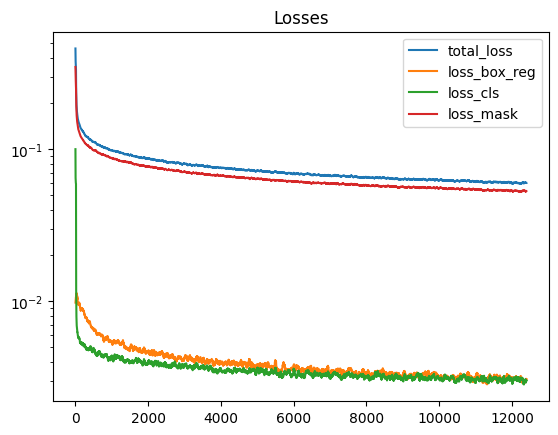

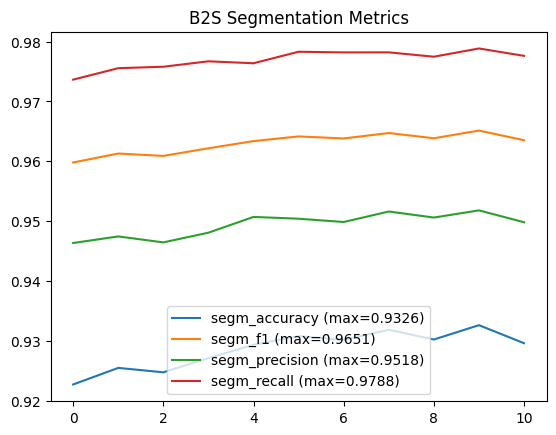

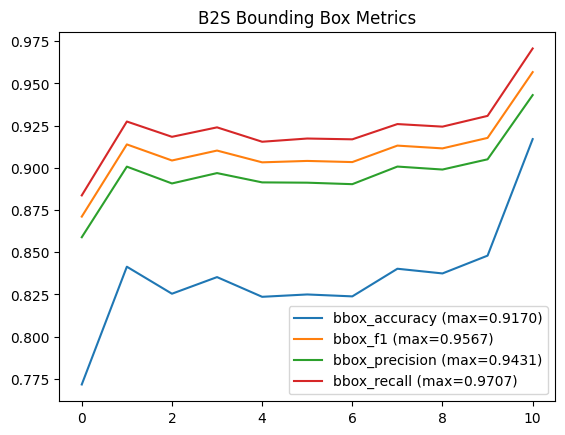

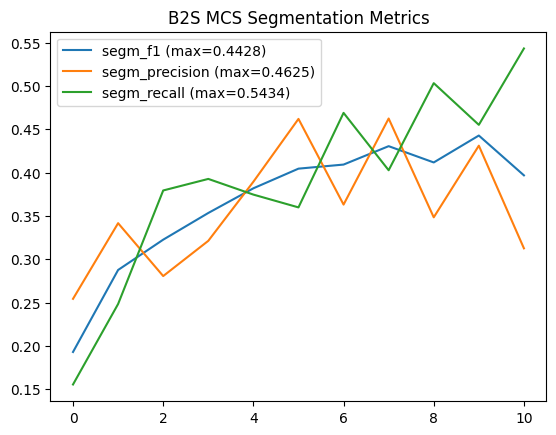

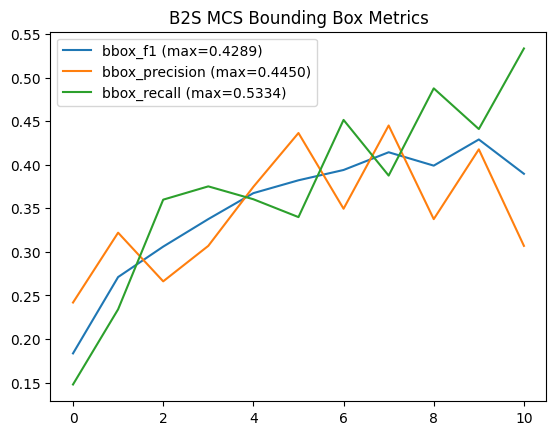

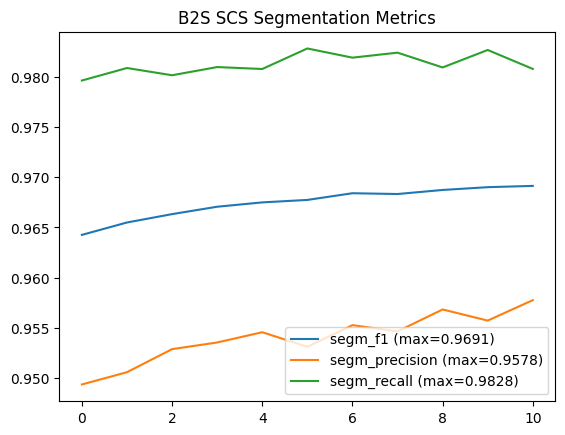

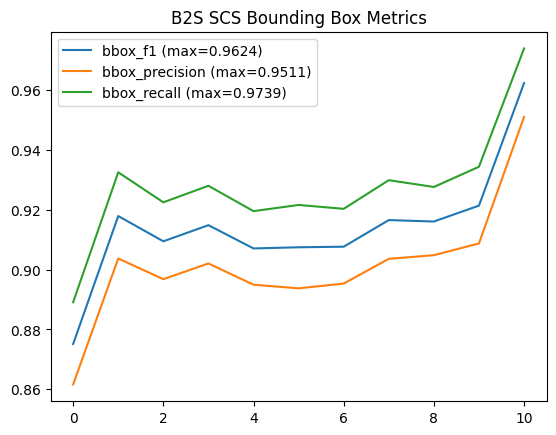

Final B2S Metrics:
MCS metrics: {'bbox_f1': [0.1834319526627219, 0.2710460943969087, 0.30597771023302933, 0.337550932875831, 0.36734693877551017, 0.38210075026795287, 0.3939267886855241, 0.41426751592356686, 0.3989081692337688, 0.42893577556225365, 0.389556135770235], 'bbox_precision': [0.24180967238689546, 0.3219672131147541, 0.2661261896369404, 0.30682261208577, 0.37462834489593655, 0.4363525091799266, 0.34944649446494463, 0.44499178981937604, 0.3375123721544045, 0.417607223476298, 0.3068275294762819], 'bbox_recall': [0.14775977121067682, 0.2340324118207817, 0.3598665395614871, 0.37511916110581506, 0.3603431839847474, 0.3398474737845567, 0.4513822688274547, 0.3875119161105815, 0.48760724499523356, 0.4408960915157293, 0.5333651096282174], 'segm_f1': [0.19289940828402366, 0.2876069555616892, 0.32259371833839917, 0.35342054471370365, 0.3819241982507289, 0.40460878885316176, 0.4093178036605658, 0.4305732484076433, 0.4117761746929226, 0.44284720612102946, 0.3968668407310705], 'segm_precis

In [4]:
display_b2s_metrics("mask_rcnn_b2s_rgz_v2")

In [5]:
import ast
import json
import re

import numpy as np

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def _make_metrics_plot(results, metric_keys, title, mask=True):
    thresholds = results["threshold"]
    extra_key = "segm" if mask else "bbox"

    plt.figure(figsize=(10, 6))
    for key, value in results.items():
        for mk in metric_keys:
            if mk in key:
                if extra_key in key:
                    max_val = max(value)
                    plt.plot(thresholds, value, label=f"{key} (max={max_val:.4f}; threshold={thresholds[np.argmax(value)]:.4f})")
    plt.xlabel("Threshold")
    plt.ylabel("Metric Value")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

def _make_tp_fp_fn_plot(results, metric_keys, title, mask=True):
    thresholds = results["threshold"]
    extra_key = "mask" if mask else "bbox"

    plt.figure(figsize=(10, 6))
    for key, value in results.items():
        for mk in metric_keys:
            if mk in key:
                if extra_key in key:
                    plt.plot(thresholds, value, label=key)
    plt.xlabel("Threshold")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()


def get_results(results_file):
    with open(results_file, "r") as f:
        results_dict = json.load(f)

    overall_source_association_results = {"threshold": []}
    overall_comp_association_results = {"threshold": []}

    source_scs_results = {"threshold": []}
    comp_scs_results = {"threshold": []}

    source_mcs_results = {"threshold": []}
    comp_mcs_results = {"threshold": []}

    for key, value in results_dict.items():
        # Append the threshold to the results dictionaries
        threshold = float(key.split("_threshold_")[-1])
        overall_source_association_results["threshold"].append(threshold)
        overall_comp_association_results["threshold"].append(threshold)
        source_scs_results["threshold"].append(threshold)
        comp_scs_results["threshold"].append(threshold)
        source_mcs_results["threshold"].append(threshold)
        comp_mcs_results["threshold"].append(threshold)

        comp_assoc = value["COMP_ASSOC"]
        comp_assoc_classwise = value["COMP_ASSOC_CLASSWISE"]

        for metric, metric_value in comp_assoc.items():
            if "_component_" in metric:
                overall_comp_association_results.setdefault(metric, []).append(metric_value)
            else:
                overall_source_association_results.setdefault(metric, []).append(metric_value)

        for metric, metric_value in comp_assoc_classwise.items():
            if "MCS_" in metric:
                if "_component_" in metric:
                    comp_mcs_results.setdefault(metric, []).append(metric_value)
                else:
                    source_mcs_results.setdefault(metric, []).append(metric_value)
            elif "SCS_" in metric:
                if "_component_" in metric:
                    comp_scs_results.setdefault(metric, []).append(metric_value)
                else:
                    source_scs_results.setdefault(metric, []).append(metric_value)

    return (
        overall_source_association_results,
        overall_comp_association_results,
        results_dict,
        source_mcs_results,
        comp_mcs_results,
        source_scs_results,
        comp_scs_results,
    )

def display_results(results_folder):  
    results_file = os.path.join(results_dir, results_folder, "results.json")
    (
        overall_source_association_results,
        overall_comp_association_results,
        results_dict,
        source_mcs_results,
        comp_mcs_results,
        source_scs_results,
        comp_scs_results,
    ) = get_results(results_file)

    metrics_keys = ["accuracy", "precision", "recall", "f1"]
    tp_fp_fn_keys = ["tp", "fp", "fn"]


    _make_metrics_plot(overall_source_association_results, metrics_keys, "Overall Source Association Metrics (Segmentation)", mask=True)
    _make_metrics_plot(overall_source_association_results, metrics_keys, "Overall Source Association Metrics (Bounding Box)", mask=False)

    _make_metrics_plot(overall_comp_association_results, metrics_keys, "Overall Component Association Metrics (Segmentation)", mask=True)
    _make_metrics_plot(overall_comp_association_results, metrics_keys, "Overall Component Association Metrics (Bounding Box)", mask=False)

    _make_metrics_plot(source_mcs_results, metrics_keys, "Source MCS Metrics (Segmentation)", mask=True)
    _make_metrics_plot(source_mcs_results, metrics_keys, "Source MCS Metrics (Bounding Box)", mask=False)

    _make_metrics_plot(comp_mcs_results, metrics_keys, "Component MCS Metrics (Segmentation)", mask=True)
    _make_metrics_plot(comp_mcs_results, metrics_keys, "Component MCS Metrics (Bounding Box)", mask=False)
    _make_metrics_plot(source_scs_results, metrics_keys, "Source SCS Metrics (Segmentation)", mask=True)
    _make_metrics_plot(source_scs_results, metrics_keys, "Source SCS Metrics (Bounding Box)", mask=False)
    _make_metrics_plot(comp_scs_results, metrics_keys, "Component SCS Metrics (Segmentation)", mask=True)
    _make_metrics_plot(comp_scs_results, metrics_keys, "Component SCS Metrics (Bounding Box)", mask=False)

    _make_tp_fp_fn_plot(overall_source_association_results, tp_fp_fn_keys, "Overall Source Association TP/FP/FN (Segmentation)", mask=True)
    _make_tp_fp_fn_plot(overall_source_association_results, tp_fp_fn_keys, "Overall Source Association TP/FP/FN (Bounding Box)", mask=False)
    _make_tp_fp_fn_plot(overall_comp_association_results, tp_fp_fn_keys, "Overall Component Association TP/FP/FN (Segmentation)", mask=True)
    _make_tp_fp_fn_plot(overall_comp_association_results, tp_fp_fn_keys, "Overall Component Association TP/FP/FN (Bounding Box)", mask=False)
    _make_tp_fp_fn_plot(source_mcs_results, tp_fp_fn_keys, "Source MCS TP/FP/FN (Segmentation)", mask=True)
    _make_tp_fp_fn_plot(source_mcs_results, tp_fp_fn_keys, "Source MCS TP/FP/FN (Bounding Box)", mask=False)
    _make_tp_fp_fn_plot(comp_mcs_results, tp_fp_fn_keys, "Component MCS TP/FP/FN (Segmentation)", mask=True)
    _make_tp_fp_fn_plot(comp_mcs_results, tp_fp_fn_keys, "Component MCS TP/FP/FN (Bounding Box)", mask=False)
    _make_tp_fp_fn_plot(source_scs_results, tp_fp_fn_keys, "Source SCS TP/FP/FN (Segmentation)", mask=True)
    _make_tp_fp_fn_plot(source_scs_results, tp_fp_fn_keys, "Source SCS TP/FP/FN (Bounding Box)", mask=False)
    _make_tp_fp_fn_plot(comp_scs_results, tp_fp_fn_keys, "Component SCS TP/FP/FN (Segmentation)", mask=True)
    _make_tp_fp_fn_plot(comp_scs_results, tp_fp_fn_keys, "Component SCS TP/FP/FN (Bounding Box)", mask=False)

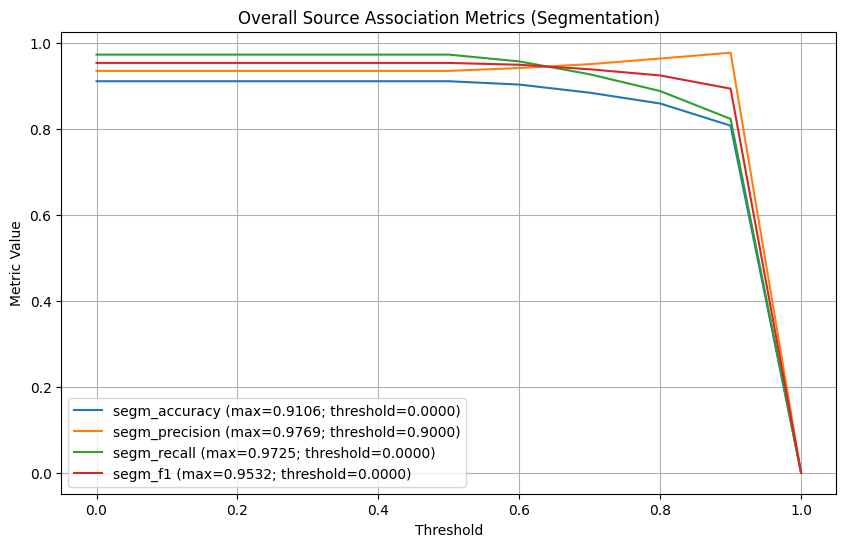

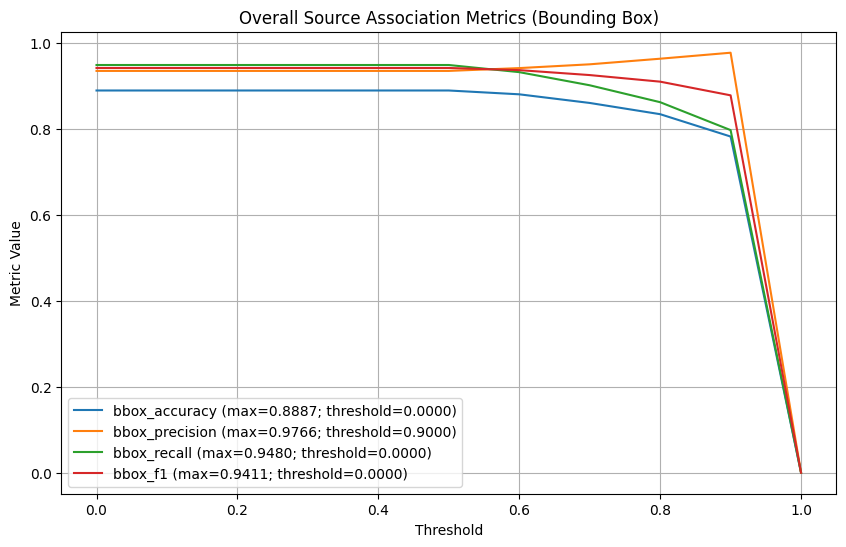

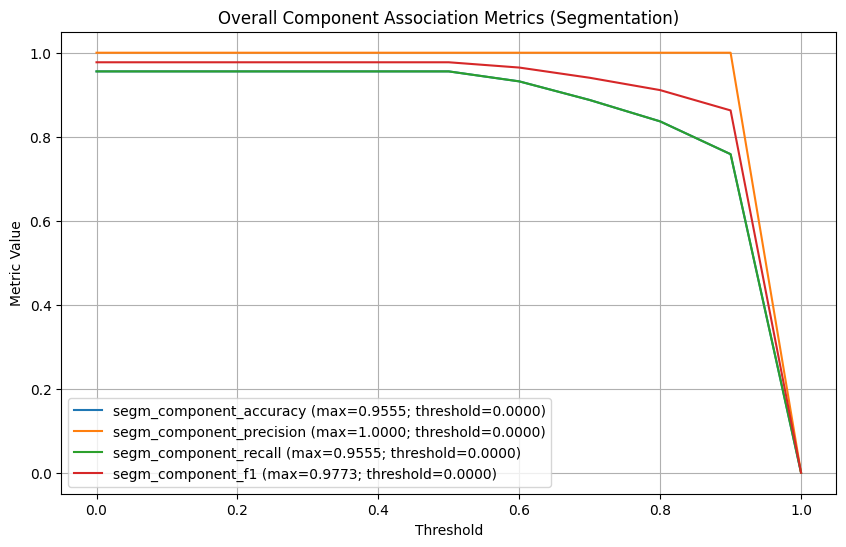

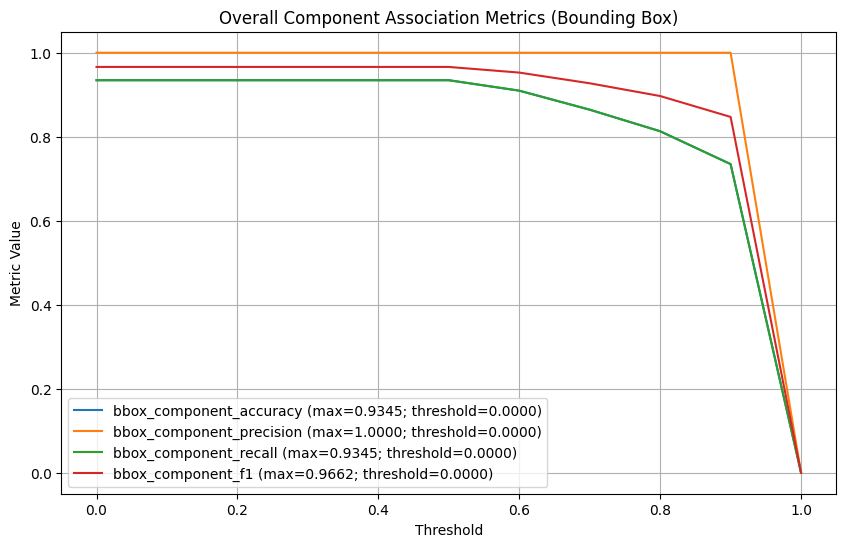

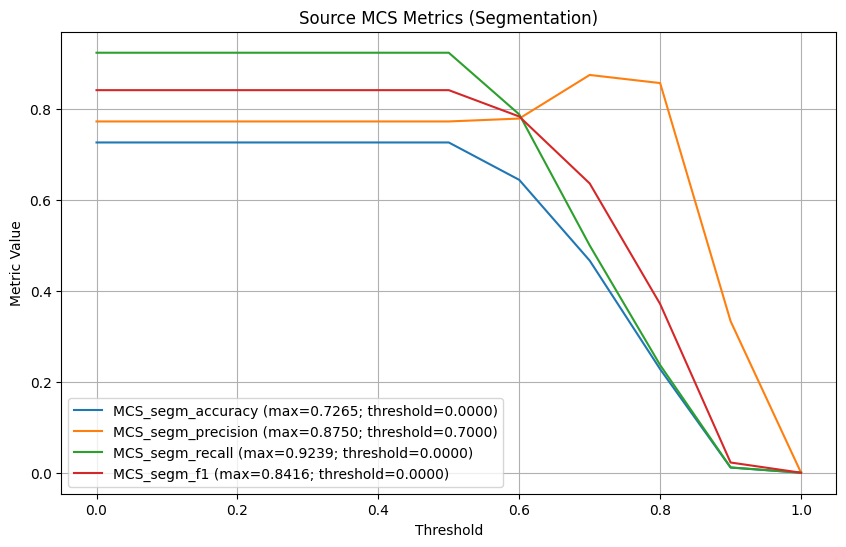

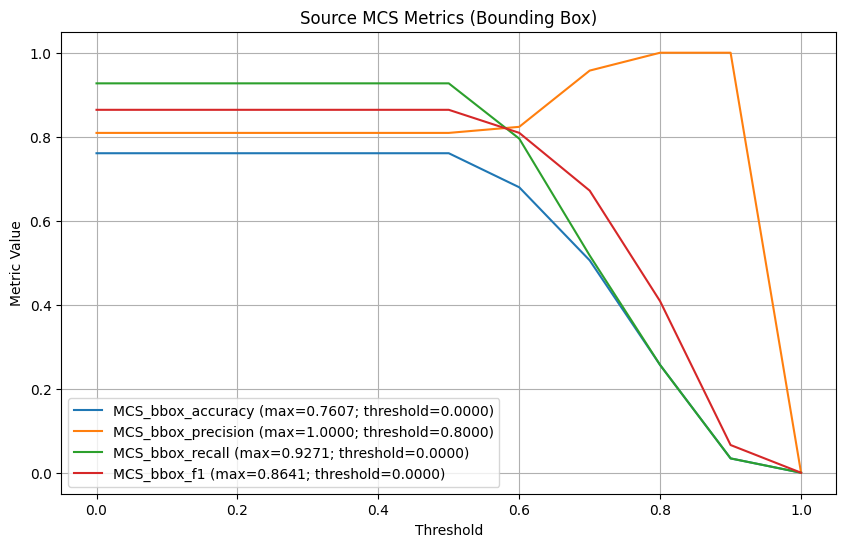

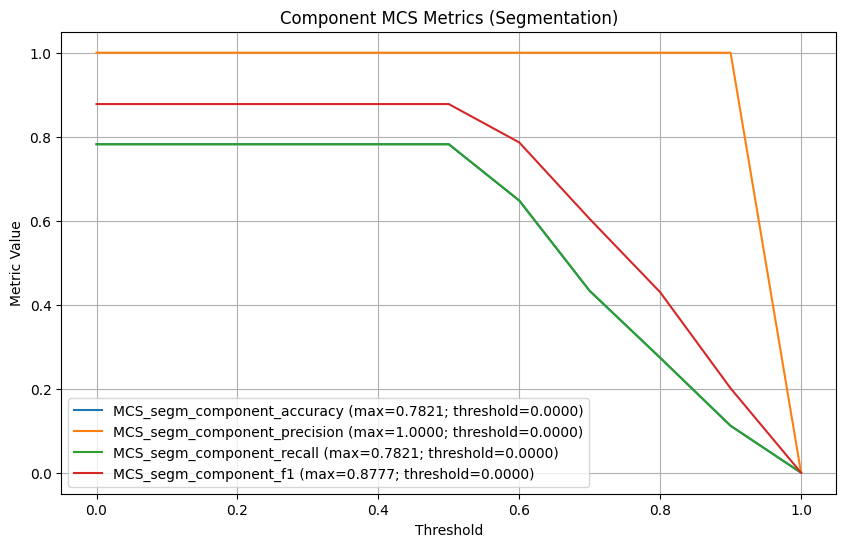

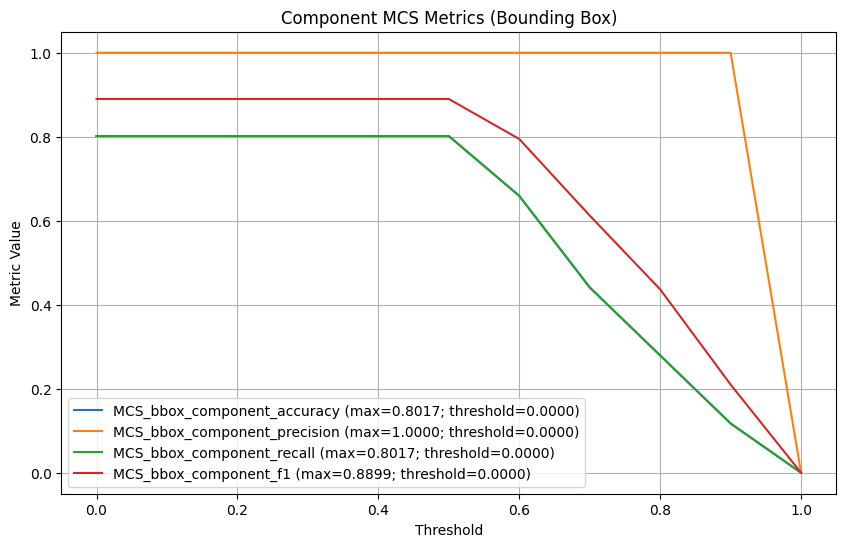

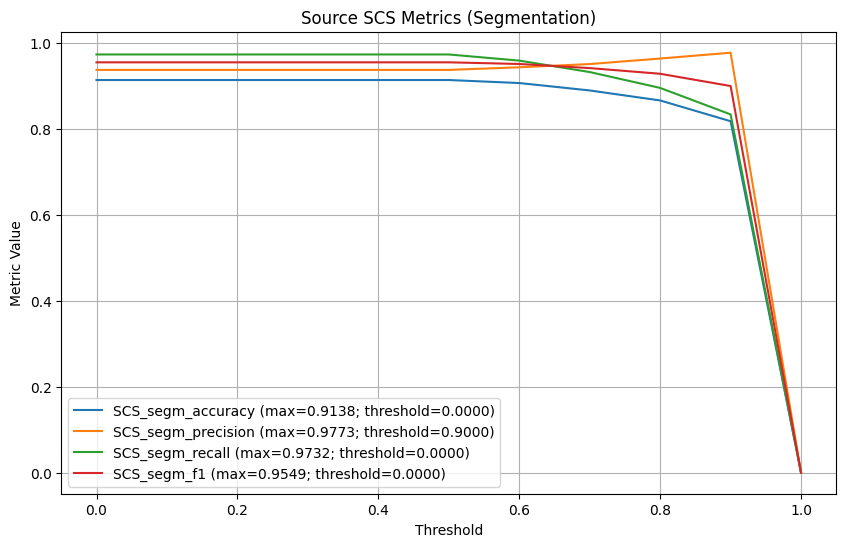

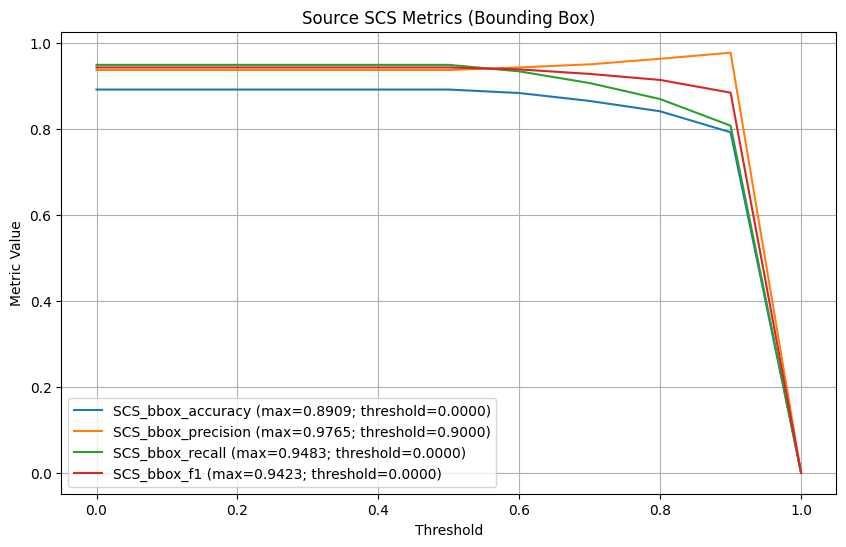

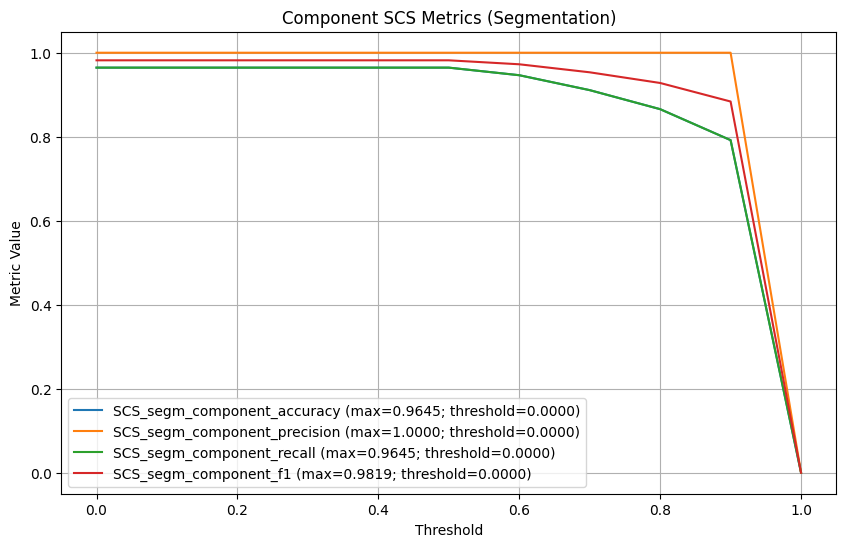

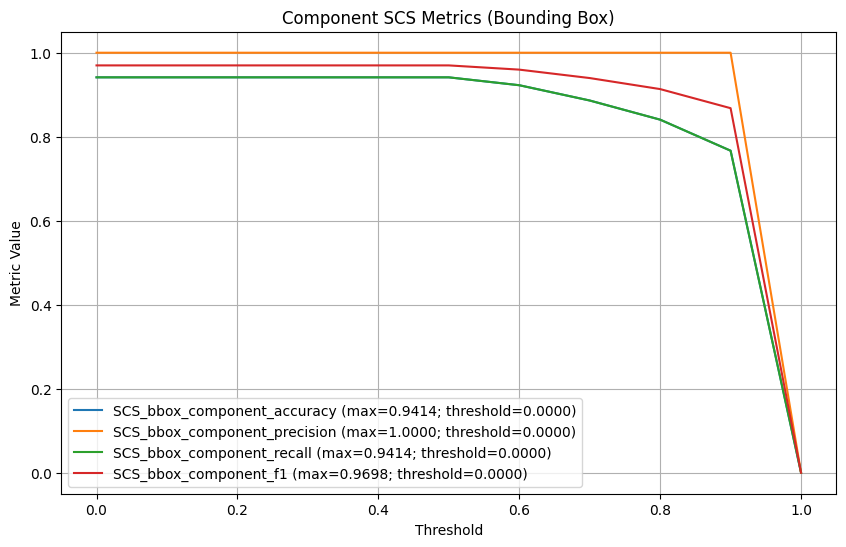

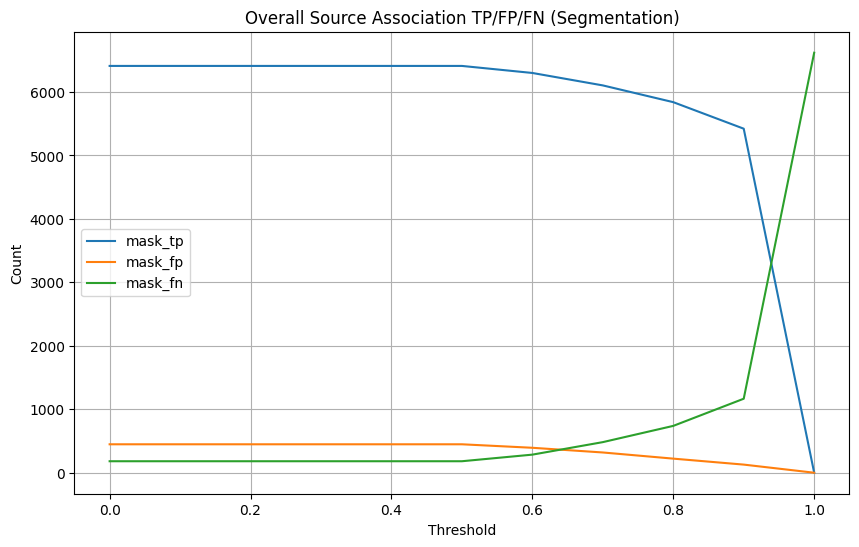

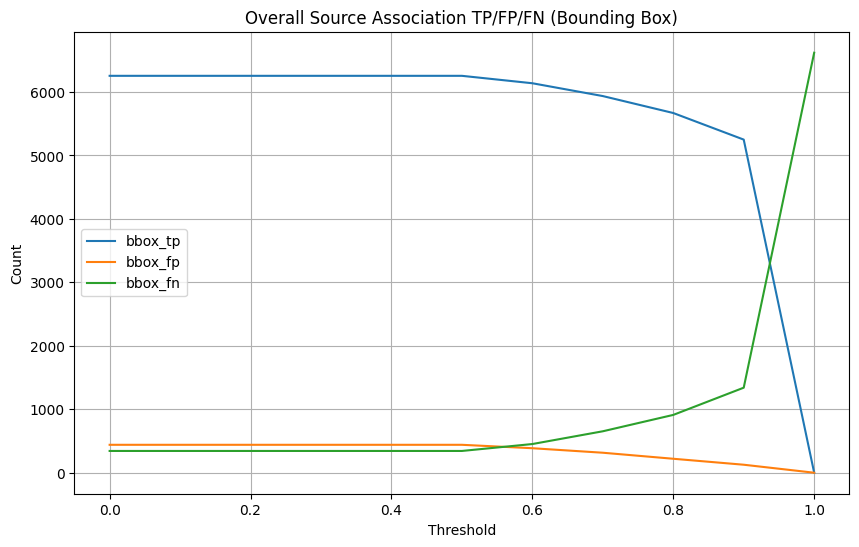

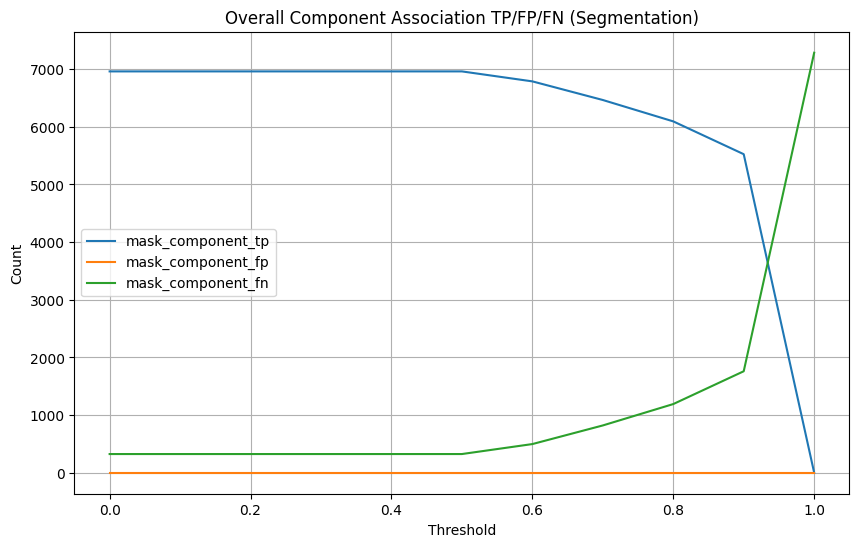

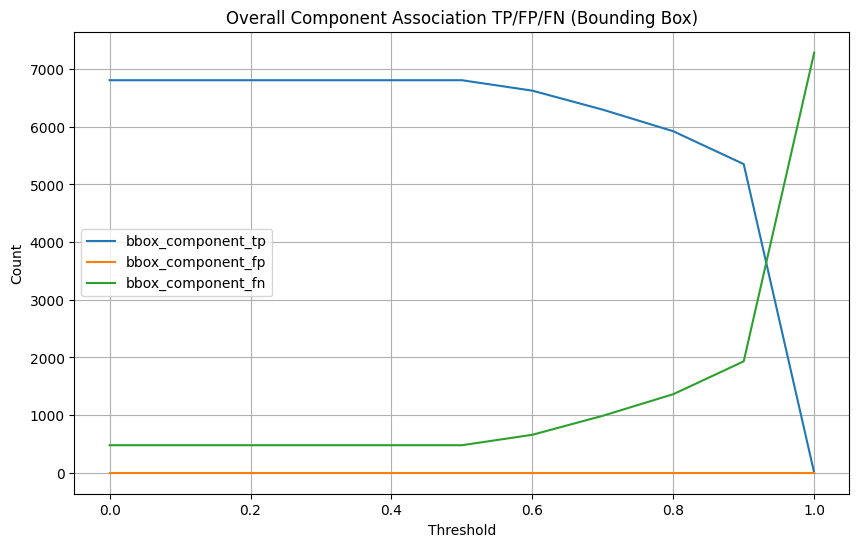

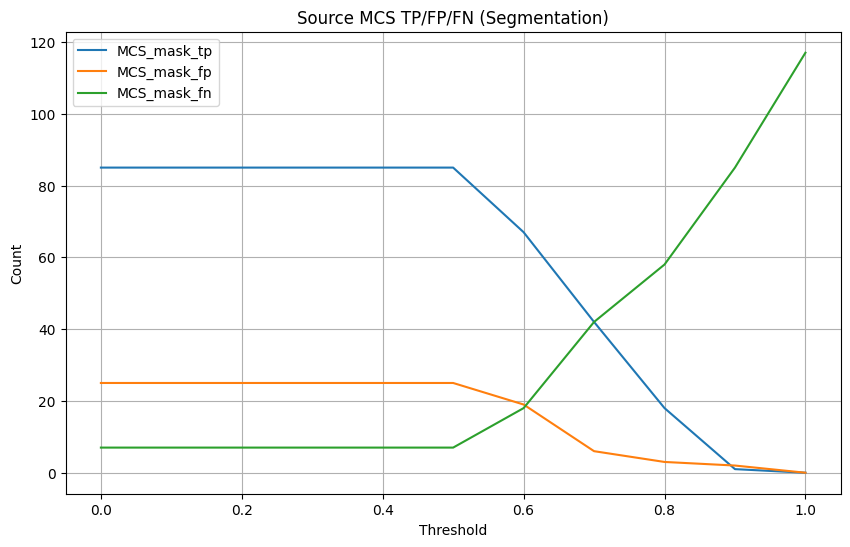

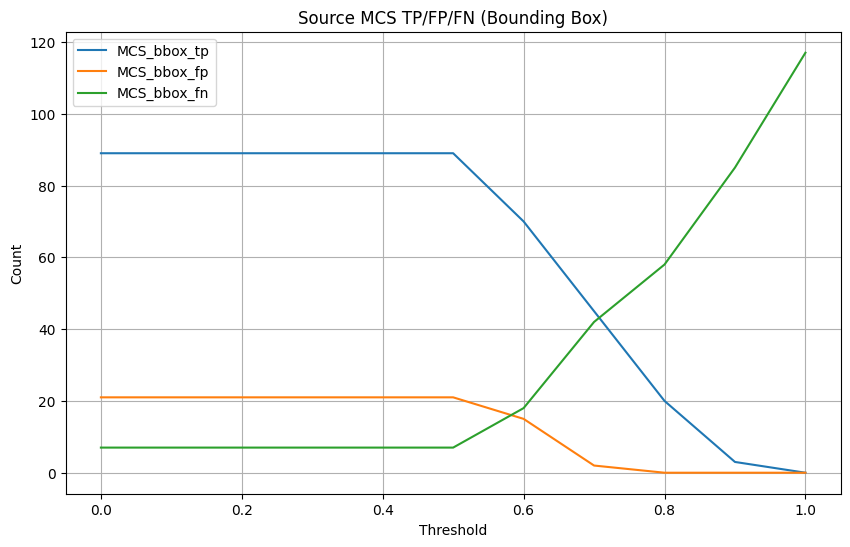

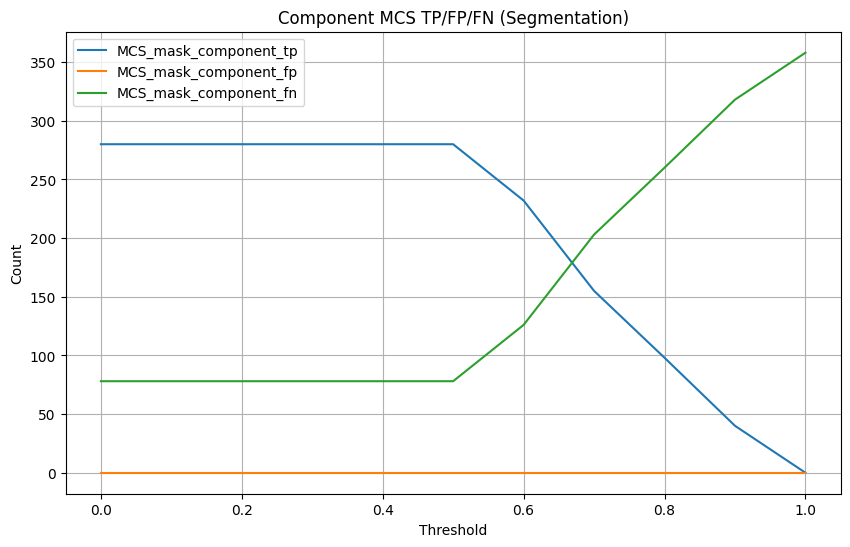

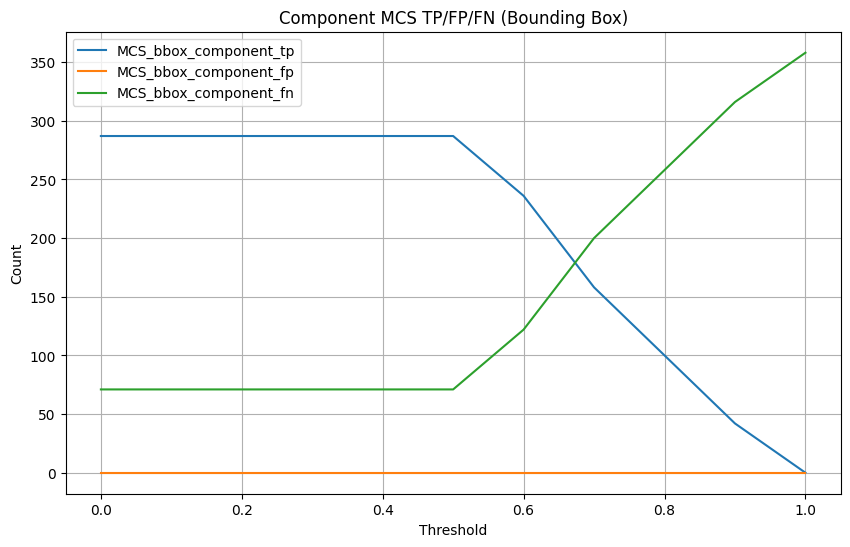

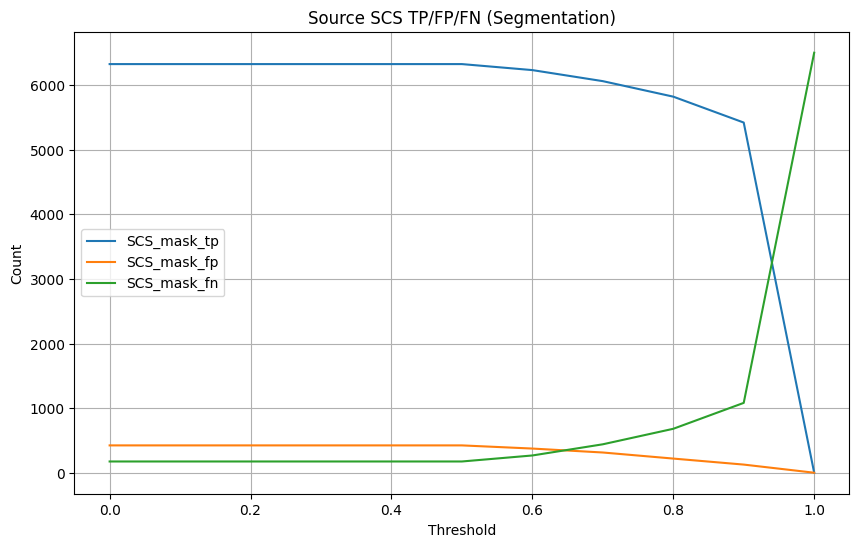

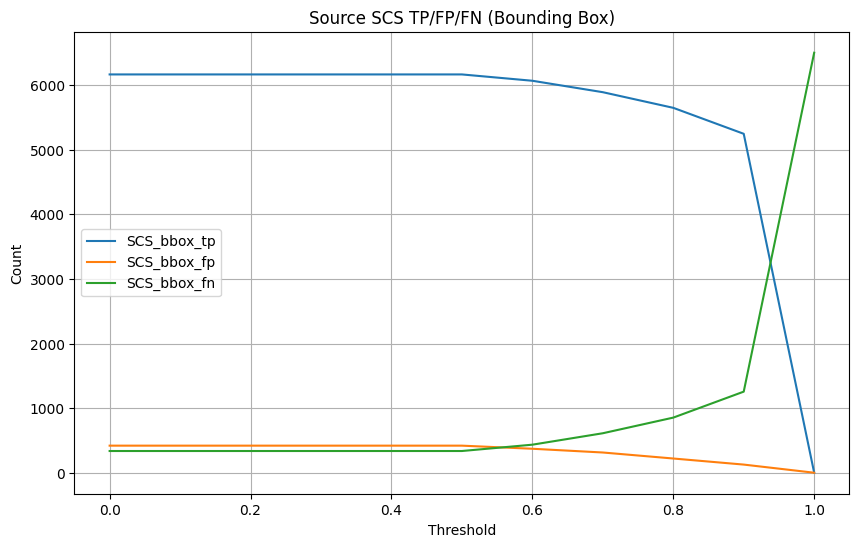

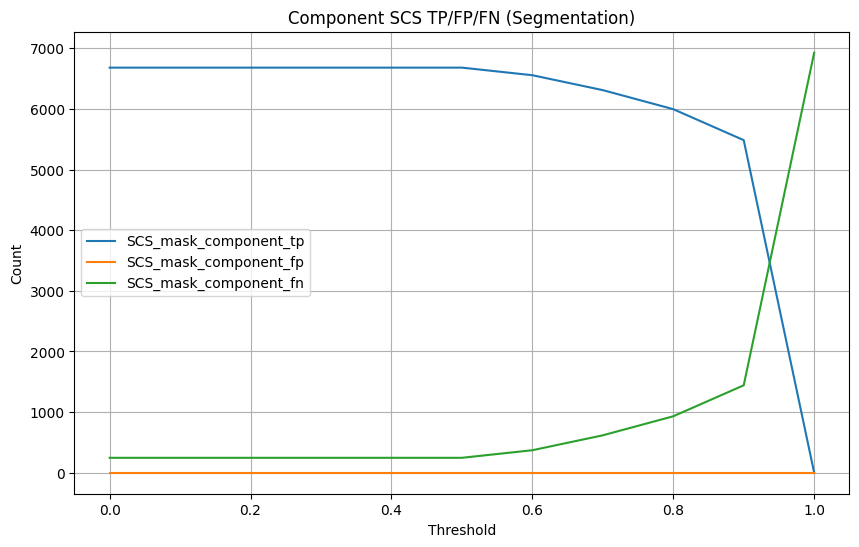

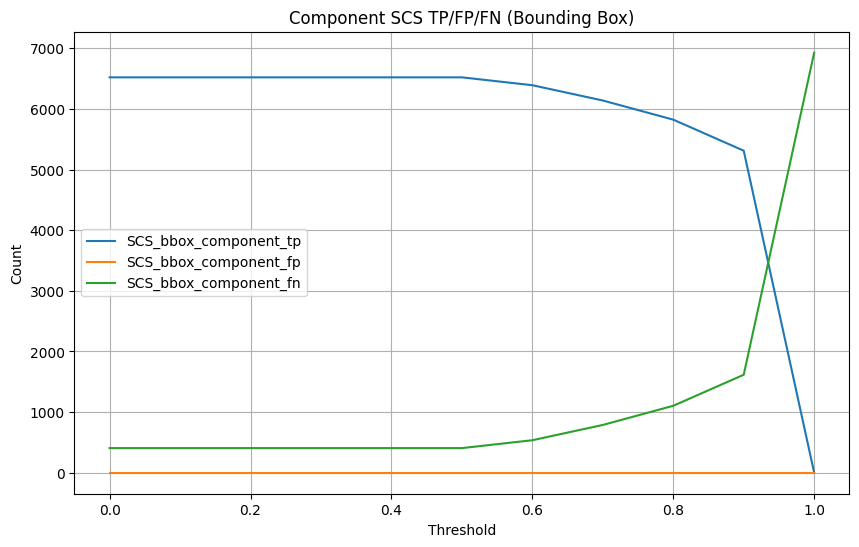

In [7]:
display_results("hs_rgz_v2")